<a href="https://colab.research.google.com/github/Kafleavinash/Machinelearning_soil/blob/main/Soil_Interpolated_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Antho_Farm_1_For_Raster.csv to Antho_Farm_1_For_Raster.csv


In [4]:
import pandas as pd

# Load the CSV (replace filename if needed)
df = pd.read_csv("/content/Antho_Farm_1_For_Raster.csv")

# Preview it
df.head()


,lati,long,OM,Predicted_OM
0,44.384,-94.121,4.79,6.490146
1,44.383,-94.121,6.39,5.329409
2,44.382,-94.121,5.19,6.081727
3,44.381,-94.121,4.10,NaN
4,44.376,-94.121,5.89,5.983556


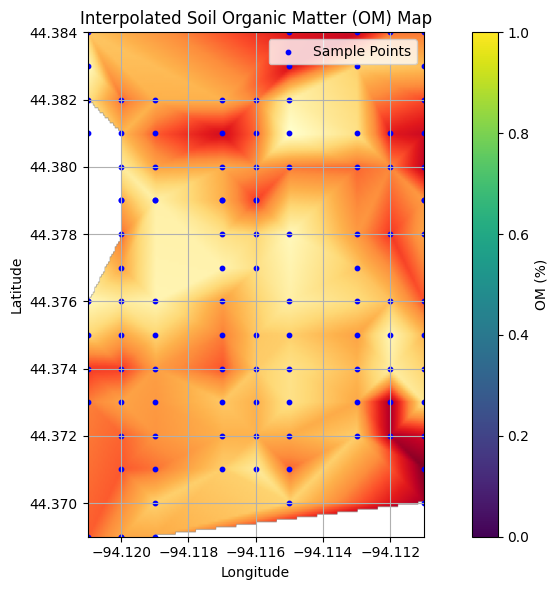

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Create grid (200x200 resolution)
grid_x, grid_y = np.mgrid[
    df['long'].min():df['long'].max():200j,
    df['lati'].min():df['lati'].max():200j
]

# Interpolate using 'linear' method (you can try 'cubic' or 'nearest')
grid_z = griddata(
    (df['long'], df['lati']), df['Predicted_OM'],
    (grid_x, grid_y), method='linear'
)

# Plot interpolated map
plt.figure(figsize=(10, 6))
plt.imshow(grid_z.T, extent=(df['long'].min(), df['long'].max(), df['lati'].min(), df['lati'].max()),
           origin='lower', cmap='YlOrRd')
plt.scatter(df['long'], df['lati'], c='blue', s=10, label='Sample Points')
plt.colorbar(label='OM (%)')
plt.title('Interpolated Soil Organic Matter (OM) Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


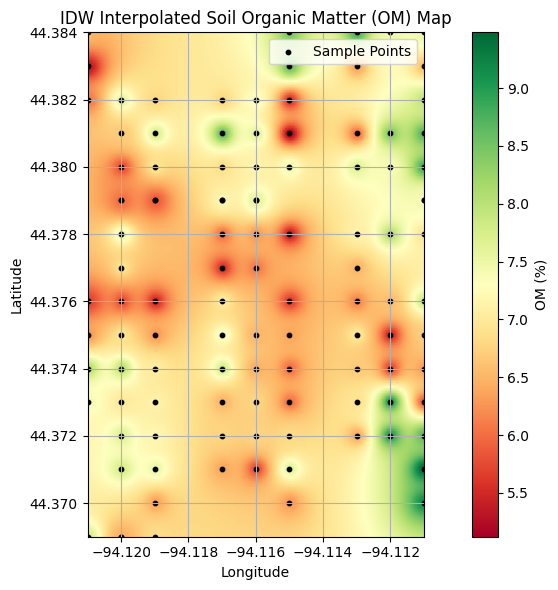

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Drop rows with NaN in Predicted_OM
df_clean = df.dropna(subset=['Predicted_OM'])

# Create grid (200x200 resolution)
grid_x, grid_y = np.mgrid[
    df_clean['long'].min():df_clean['long'].max():200j,
    df_clean['lati'].min():df_clean['lati'].max():200j
]

# Define IDW interpolation function
def inverse_distance_weighting(xy, values, grid, power=2):
    grid_x, grid_y = grid
    grid_z = np.empty_like(grid_x)

    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):
            distances = np.sqrt((grid_x[i, j] - xy[:, 0])**2 + (grid_y[i, j] - xy[:, 1])**2)
            if np.min(distances) == 0:
                grid_z[i, j] = values[np.argmin(distances)]
            else:
                weights = 1.0 / (distances**power)
                normalized_weights = weights / np.sum(weights)
                grid_z[i, j] = np.sum(normalized_weights * values)
    return grid_z

# Extract coordinates and values
xy = df_clean[['long', 'lati']].values
values = df_clean['Predicted_OM'].values

# Perform IDW interpolation
grid_z = inverse_distance_weighting(xy, values, (grid_x, grid_y), power=2)

# Plot the interpolated result
plt.figure(figsize=(10, 6))
c = plt.imshow(grid_z.T, extent=(df_clean['long'].min(), df_clean['long'].max(),
                                 df_clean['lati'].min(), df_clean['lati'].max()),
               origin='lower', cmap='RdYlGn', vmin=values.min(), vmax=values.max())

plt.scatter(df_clean['long'], df_clean['lati'], c='black', s=10, label='Sample Points')
plt.colorbar(c, label='OM (%)')
plt.title('IDW Interpolated Soil Organic Matter (OM) Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


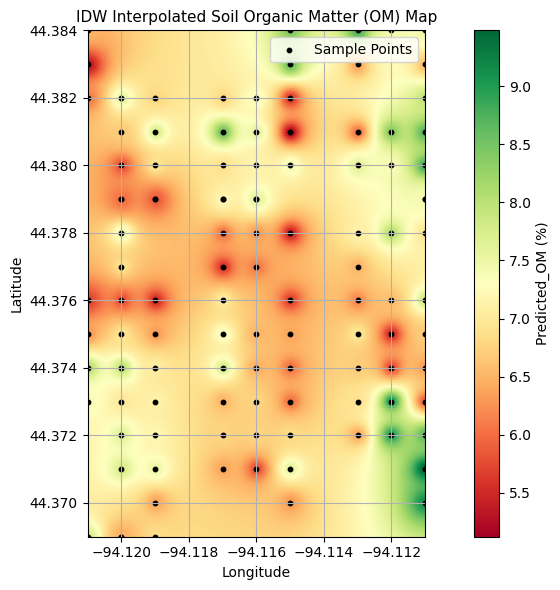

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Drop rows where Predicted_OM is NaN
df_clean = df.dropna(subset=['Predicted_OM'])

# Step 2: Create a grid for interpolation (200 x 200 resolution)
grid_x, grid_y = np.mgrid[
    df_clean['long'].min():df_clean['long'].max():200j,
    df_clean['lati'].min():df_clean['lati'].max():200j
]

# Step 3: Define the Inverse Distance Weighting (IDW) interpolation function
def inverse_distance_weighting(xy, values, grid, power=2):
    grid_x, grid_y = grid
    grid_z = np.empty_like(grid_x)

    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):
            distances = np.sqrt((grid_x[i, j] - xy[:, 0])**2 + (grid_y[i, j] - xy[:, 1])**2)
            if np.min(distances) == 0:
                grid_z[i, j] = values[np.argmin(distances)]
            else:
                weights = 1.0 / (distances ** power)
                normalized_weights = weights / np.sum(weights)
                grid_z[i, j] = np.sum(normalized_weights * values)
    return grid_z

# Step 4: Prepare the input for IDW
xy = df_clean[['long', 'lati']].values
values = df_clean['Predicted_OM'].values

# Step 5: Run the IDW interpolation
grid_z = inverse_distance_weighting(xy, values, (grid_x, grid_y), power=2)

# Step 6: Plot the result with RYG (Red-Yellow-Green) colormap
plt.figure(figsize=(10, 6))
c = plt.imshow(grid_z.T, extent=(df_clean['long'].min(), df_clean['long'].max(),
                                 df_clean['lati'].min(), df_clean['lati'].max()),
               origin='lower', cmap='RdYlGn', vmin=values.min(), vmax=values.max())

plt.scatter(df_clean['long'], df_clean['lati'], c='black', s=10, label='Sample Points')
plt.colorbar(c, label='Predicted_OM (%)')
plt.title('IDW Interpolated Soil Organic Matter (OM) Map', fontsize=11)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


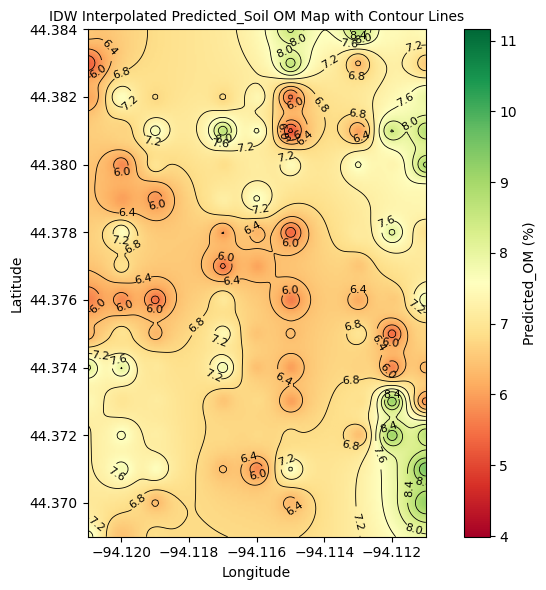

In [27]:
# Plot with Red-Yellow-Green colormap and contour lines
plt.figure(figsize=(8, 6))

# Show the raster
c = plt.imshow(
    grid_z.T,
    extent=(df['long'].min(), df['long'].max(), df['lati'].min(), df['lati'].max()),
    origin='lower',
    cmap='RdYlGn',
    vmin=df['OM'].min(),
    vmax=df['OM'].max()
)

# Add contour lines
contours = plt.contour(
    grid_x, grid_y, grid_z,
    levels=10,                  # Number of contour lines
    colors='black',
    linewidths=0.6
)
plt.clabel(contours, inline=True, fontsize=8, fmt="%.1f")

# Add colorbar and labels
plt.colorbar(c, label='Predicted_OM (%)')
plt.title('IDW Interpolated Predicted_Soil OM Map with Contour Lines',fontsize=10),
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.tight_layout()
plt.show()


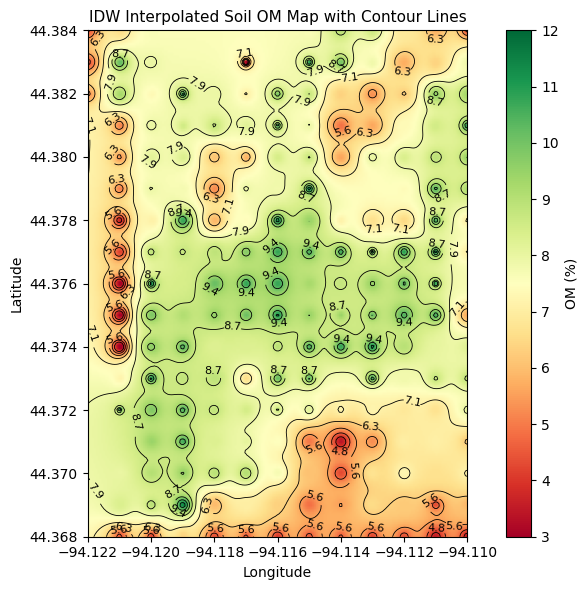

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot with Red-Yellow-Green colormap and contour lines
plt.figure(figsize=(8, 6))

# Show the raster with fixed OM range
c = plt.imshow(
    grid_z.T,
    extent=(df['long'].min(), df['long'].max(), df['lat'].min(), df['lat'].max()),
    origin='lower',
    cmap='RdYlGn',
    vmin=3,
    vmax=12
)

# Add contour lines with fixed levels
contours = plt.contour(
    grid_x, grid_y, grid_z,
    levels=np.linspace(4, 11, num=10),
    colors='black',
    linewidths=0.6
)
plt.clabel(contours, inline=True, fontsize=8, fmt="%.1f")

# Add colorbar and labels
plt.colorbar(c, label='OM (%)')
plt.title('IDW Interpolated Soil OM Map with Contour Lines', fontsize=11)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.tight_layout()
plt.show()
